In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input/assigment1'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/assigment1/Dataset/Dataset/annotations/2015_val.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/2576_aro.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/5125_aro.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/3834_lnd.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/1589_val.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/4481_lnd.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/4508_aro.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/2820_exp.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/2552_lnd.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/3169_lnd.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/1757_exp.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/2691_exp.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/4207_val.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/406_exp.npy
/kaggle/input/assigment1/Dataset/Dataset/annotations/4112_lnd.npy
/kaggle/inp

In [2]:
import os, random, math, sys
from glob import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc, confusion_matrix
from scipy.stats import pearsonr
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

# ------------------------------
# Settings
# ------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_ROOT = "/kaggle/input/assigment1"
IMAGES_DIR = os.path.join(DATA_ROOT, "Dataset", "Dataset", "images")
ANN_DIR = os.path.join(DATA_ROOT, "Dataset", "Dataset", "annotations")
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 8

2025-09-27 13:02:35.659608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758978156.012794      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758978156.117584      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# ------------------------------
# 1) Loader
# ------------------------------
def load_from_perfile(images_dir=IMAGES_DIR, ann_dir=ANN_DIR):
    img_paths = sorted(glob(os.path.join(images_dir, "*.jpg")))
    rows = []
    for p in tqdm(img_paths, desc="Loading annotations"):
        stem = os.path.splitext(os.path.basename(p))[0]
        exp_f = os.path.join(ann_dir, f"{stem}_exp.npy")
        val_f = os.path.join(ann_dir, f"{stem}_val.npy")
        aro_f = os.path.join(ann_dir, f"{stem}_aro.npy")
        if os.path.exists(exp_f) and os.path.exists(val_f) and os.path.exists(aro_f):
            try:
                exp = int(np.load(exp_f).item())
                val = float(np.load(val_f).item())
                aro = float(np.load(aro_f).item())
                rows.append((p, exp, val, aro))
            except Exception:
                continue
    return pd.DataFrame(rows, columns=["image","expression","valence","arousal"])

df = load_from_perfile()
print("Samples loaded:", len(df))
print(df.head())
print("Expression counts:\n", df['expression'].value_counts())

# ------------------------------
# 2) Train/Val/Test split
# ------------------------------
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df['expression'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['expression'])
print("Split sizes:", len(train_df), len(val_df), len(test_df))


Loading annotations: 100%|██████████| 3999/3999 [01:52<00:00, 35.42it/s]


Samples loaded: 3999
                                               image  expression   valence  \
0  /kaggle/input/assigment1/Dataset/Dataset/image...           0 -0.176846   
1  /kaggle/input/assigment1/Dataset/Dataset/image...           0 -0.367789   
2  /kaggle/input/assigment1/Dataset/Dataset/image...           7 -0.648471   
3  /kaggle/input/assigment1/Dataset/Dataset/image...           3  0.150794   
4  /kaggle/input/assigment1/Dataset/Dataset/image...           0 -0.135501   

    arousal  
0 -0.077640  
1  0.183895  
2  0.658149  
3  0.666667  
4  0.004839  
Expression counts:
 expression
0    500
3    500
4    500
5    500
6    500
2    500
1    500
7    499
Name: count, dtype: int64
Split sizes: 3199 400 400


In [4]:
# ------------------------------
# 3) tf.data pipeline
# ------------------------------
def _parse_and_preprocess(path, exp, val, aro, training=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_hue(img, 0.05)
        if tf.random.uniform(()) < 0.3:
            crop = tf.image.random_crop(img, size=[int(IMG_SIZE*0.9), int(IMG_SIZE*0.9), 3])
            img = tf.image.resize(crop, [IMG_SIZE, IMG_SIZE])
    labels = {"exp_out": tf.cast(exp, tf.int32),
              "va_out": tf.stack([tf.cast(val, tf.float32), tf.cast(aro, tf.float32)])}
    return img, labels

def make_ds(df, batch=BATCH_SIZE, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['image'].values, df['expression'].values, df['valence'].values, df['arousal'].values))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p,e,v,a: _parse_and_preprocess(p,e,v,a,training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)
test_ds  = make_ds(test_df, training=False)


I0000 00:00:1758978382.908592      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758978382.909285      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
# ------------------------------
# 4) Model builder
# ------------------------------
def build_multitask_model(backbone="mobilenet", input_shape=(IMG_SIZE,IMG_SIZE,3), num_classes=NUM_CLASSES, dropout=0.4, pretrained=True):
    inp = keras.Input(shape=input_shape)
    if backbone == "mobilenet":
        base = keras.applications.MobileNetV2(include_top=False, input_tensor=inp, weights="imagenet" if pretrained else None, pooling='avg')
    elif backbone == "efficientnet":
        base = keras.applications.EfficientNetB0(include_top=False, input_tensor=inp, weights="imagenet" if pretrained else None, pooling='avg')
    x = base.output
    x = layers.Dropout(dropout)(x)
    cls = layers.Dense(256, activation='relu')(x)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.3)(cls)
    exp_out = layers.Dense(num_classes, activation='softmax', name='exp_out')(cls)
    reg = layers.Dense(128, activation='relu')(x)
    reg = layers.BatchNormalization()(reg)
    reg = layers.Dropout(0.3)(reg)
    va_out = layers.Dense(2, activation='tanh', name='va_out')(reg)
    return keras.Model(inputs=inp, outputs=[exp_out, va_out])


In [6]:
# ------------------------------
# 5) Losses / metrics
# ------------------------------
class SparseCrossEntropyWithSmoothing(keras.losses.Loss):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_true = y_true * (1 - self.smoothing) + self.smoothing / NUM_CLASSES
        return tf.reduce_mean(keras.losses.categorical_crossentropy(y_true, y_pred))

losses = {
    "exp_out": SparseCrossEntropyWithSmoothing(smoothing=0.1),
    "va_out": "mse"
}
loss_weights = {"exp_out": 1.0, "va_out": 0.4}
metrics = {"exp_out": ["accuracy"], "va_out": ["mae"]}

In [7]:
# ------------------------------
# 6) Training function
# ------------------------------
def compile_and_train(model, train_ds, val_ds, model_name="model", stage1_epochs=25, finetune_epochs=15, unfreeze_from=-60):
    # Stage 1
    for layer in model.layers:
        if any(k in layer.name.lower() for k in ["mobilenetv2","efficientnet"]):
            layer.trainable = False
    lr_schedule = keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=1000)
    model.compile(optimizer=keras.optimizers.Adam(lr_schedule), loss=losses, loss_weights=loss_weights, metrics=metrics)
    print(f"--- Training {model_name} Stage 1 ---")
    history1 = model.fit(train_ds, validation_data=val_ds, epochs=stage1_epochs, verbose=2)

    # Stage 2: fine-tuning
    print(f"--- Fine-tuning {model_name} ---")
    model.trainable = True
    total = len(model.layers)
    for i, layer in enumerate(model.layers[:total+unfreeze_from]):
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5), loss=losses, loss_weights=loss_weights, metrics=metrics)
    history2 = model.fit(train_ds, validation_data=val_ds, epochs=finetune_epochs, verbose=2)

    history = {}
    for k in history1.history:
        history[k] = history1.history.get(k, []) + history2.history.get(k, [])
    return model, history

In [8]:
# ------------------------------
# 7) Train models
# ------------------------------
mobilenet = build_multitask_model("mobilenet")
mobilenet, hist_m_all = compile_and_train(mobilenet, train_ds, val_ds, model_name="MobileNetV2")

efficient = build_multitask_model("efficientnet")
efficient, hist_e_all = compile_and_train(efficient, train_ds, val_ds, model_name="EfficientNetB0")


/tmp/ipykernel_36/2541536233.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(include_top=False, input_tensor=inp, weights="imagenet" if pretrained else None, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Training MobileNetV2 Stage 1 ---
Epoch 1/25


I0000 00:00:1758978436.426579     120 service.cc:148] XLA service 0x7e4670005e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758978436.428427     120 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758978436.428448     120 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758978439.982215     120 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758978461.153108     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 - 102s - 1s/step - exp_out_accuracy: 0.1916 - exp_out_loss: 2.5708 - loss: 2.8281 - va_out_loss: 0.6428 - va_out_mae: 0.6551 - val_exp_out_accuracy: 0.1375 - val_exp_out_loss: 8.7416 - val_loss: 8.9720 - val_va_out_loss: 0.5347 - val_va_out_mae: 0.6149
Epoch 2/25
100/100 - 10s - 101ms/step - exp_out_accuracy: 0.2779 - exp_out_loss: 2.0999 - loss: 2.2296 - va_out_loss: 0.3240 - va_out_mae: 0.4530 - val_exp_out_accuracy: 0.1700 - val_exp_out_loss: 7.1742 - val_loss: 7.5644 - val_va_out_loss: 0.9419 - val_va_out_mae: 0.8408
Epoch 3/25
100/100 - 10s - 104ms/step - exp_out_accuracy: 0.3507 - exp_out_loss: 1.8854 - loss: 1.9759 - va_out_loss: 0.2264 - va_out_mae: 0.3755 - val_exp_out_accuracy: 0.1950 - val_exp_out_loss: 3.1815 - val_loss: 3.4391 - val_va_out_loss: 0.6532 - val_va_out_mae: 0.6866
Epoch 4/25
100/100 - 11s - 106ms/step - exp_out_accuracy: 0.4108 - exp_out_loss: 1.7384 - loss: 1.8192 - va_out_loss: 0.2020 - va_out_mae: 0.3527 - val_exp_out_accuracy: 0.1850 - val_exp_out_

E0000 00:00:1758978939.703750     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758978939.847397     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758978940.323061     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758978940.464050     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758978986.544427     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

100/100 - 150s - 2s/step - exp_out_accuracy: 0.2054 - exp_out_loss: 2.5577 - loss: 2.7997 - va_out_loss: 0.6047 - va_out_mae: 0.6271 - val_exp_out_accuracy: 0.1250 - val_exp_out_loss: 2.1039 - val_loss: 2.1818 - val_va_out_loss: 0.1967 - val_va_out_mae: 0.3585
Epoch 2/25
100/100 - 14s - 143ms/step - exp_out_accuracy: 0.2976 - exp_out_loss: 2.0492 - loss: 2.1579 - va_out_loss: 0.2721 - va_out_mae: 0.4124 - val_exp_out_accuracy: 0.1250 - val_exp_out_loss: 2.1527 - val_loss: 2.2294 - val_va_out_loss: 0.1881 - val_va_out_mae: 0.3577
Epoch 3/25
100/100 - 15s - 151ms/step - exp_out_accuracy: 0.3492 - exp_out_loss: 1.8990 - loss: 1.9866 - va_out_loss: 0.2189 - va_out_mae: 0.3719 - val_exp_out_accuracy: 0.1250 - val_exp_out_loss: 2.1964 - val_loss: 2.2661 - val_va_out_loss: 0.1877 - val_va_out_mae: 0.3611
Epoch 4/25
100/100 - 14s - 143ms/step - exp_out_accuracy: 0.4111 - exp_out_loss: 1.7643 - loss: 1.8404 - va_out_loss: 0.1901 - va_out_mae: 0.3453 - val_exp_out_accuracy: 0.1350 - val_exp_out_

In [11]:
# ===============================================
# 📊 Evaluation, Metrics, Graphs, Comparisons
# ===============================================

# --- Krippendorff’s Alpha (nominal, 2-rater approx) ---
def krippendorff_alpha_nominal(y_true, y_pred):
    n = len(y_true)
    if n == 0: return np.nan
    categories = np.unique(np.concatenate([y_true, y_pred]))
    m = len(categories)
    cat2idx = {c:i for i,c in enumerate(categories)}
    # observed disagreement
    Do = np.mean([a != b for a,b in zip(y_true,y_pred)])
    # expected disagreement
    counts = np.zeros(m)
    for t in y_true: counts[cat2idx[t]] += 1
    for p in y_pred: counts[cat2idx[p]] += 1
    counts = counts / (2*n)
    De = 1.0 - np.sum(counts**2)
    return 1 - (Do/De) if De > 0 else 1.0

# --- Classification metrics ---
def compute_classification_metrics(y_true, y_pred_prob):
    y_pred = np.argmax(y_pred_prob, axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred)
    kr_alpha = krippendorff_alpha_nominal(y_true, y_pred)
    aucs, pr_aucs = [], []
    for c in range(y_pred_prob.shape[1]):
        y_true_c = (y_true == c).astype(int)
        y_score_c = y_pred_prob[:, c]
        if len(np.unique(y_true_c)) > 1:
            aucs.append(roc_auc_score(y_true_c, y_score_c))
            prec, rec, _ = precision_recall_curve(y_true_c, y_score_c)
            pr_aucs.append(auc(rec, prec))
    auc_mean = np.nanmean(aucs)
    pr_auc_mean = np.nanmean(pr_aucs)
    return {
        "accuracy": acc, "f1_weighted": f1, "kappa": kappa,
        "krippendorff_alpha": kr_alpha,
        "auc_ovr": auc_mean, "pr_auc_ovr": pr_auc_mean,
        "y_pred": y_pred
    }

# --- Regression metrics ---
def compute_regression_metrics(y_true, y_pred):
    rmse_v = np.sqrt(np.mean((y_true[:,0] - y_pred[:,0])**2))
    rmse_a = np.sqrt(np.mean((y_true[:,1] - y_pred[:,1])**2))
    rmse = (rmse_v + rmse_a)/2.0
    corr_v = pearsonr(y_true[:,0], y_pred[:,0])[0]
    corr_a = pearsonr(y_true[:,1], y_pred[:,1])[0]
    corr_mean = np.nanmean([corr_v, corr_a])
    # --- SAGR ---
    sagr = np.mean((np.sign(y_true) == np.sign(y_pred)).all(axis=1))
    # --- CCC ---
    def ccc(a,b):
        a_mean, b_mean = a.mean(), b.mean()
        cov = np.mean((a-a_mean)*(b-b_mean))
        return (2*cov) / (a.var()+b.var()+(a_mean-b_mean)**2+1e-8)
    ccc_v = ccc(y_true[:,0], y_pred[:,0])
    ccc_a = ccc(y_true[:,1], y_pred[:,1])
    ccc_mean = np.mean([ccc_v, ccc_a])
    return {"rmse": rmse, "corr_mean": corr_mean, "sagr": sagr, "ccc_mean": ccc_mean}

# --- Gather predictions ---
def gather_predictions(model, ds):
    y_true_exp, y_true_va = [], []
    y_pred_exp_prob, y_pred_va = [], []
    for x, y in ds:
        preds = model.predict(x, verbose=0)
        exp_prob, va_pred = preds[0], preds[1]
        y_true_exp.append(y['exp_out'].numpy())
        y_true_va.append(y['va_out'].numpy())
        y_pred_exp_prob.append(exp_prob)
        y_pred_va.append(va_pred)
    return (np.concatenate(y_true_exp),
            np.concatenate(y_pred_exp_prob),
            np.concatenate(y_true_va),
            np.concatenate(y_pred_va))

# --- Plot training curves ---
def plot_history(history, title="Model"):
    acc = history.get('exp_out_accuracy', [])
    val_acc = history.get('val_exp_out_accuracy', [])
    loss = history.get('loss', [])
    val_loss = history.get('val_loss', [])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot([a*100 for a in acc], label='Train Acc (%)')
    plt.plot([a*100 for a in val_acc], label='Val Acc (%)')
    plt.title(f"{title} Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
    plt.legend(); plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss'); plt.plot(val_loss, label='Val Loss')
    plt.title(f"{title} Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True); plt.show()

# --- Confusion matrix ---
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()
    return cm

# --- Show correct/incorrect examples ---
def show_examples(model, df, n=8):
    samp = df.sample(n, random_state=SEED)
    imgs = []
    for p in samp['image'].values:
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        imgs.append(img.numpy())
    imgs = np.stack(imgs)
    preds = model.predict(imgs, verbose=0)
    pred_exp = np.argmax(preds[0], axis=1)
    real = samp['expression'].values
    fig, axes = plt.subplots(2, n//2, figsize=(16,6))
    axes = axes.ravel()
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i]); ax.axis('off')
        color = 'g' if pred_exp[i]==real[i] else 'r'
        ax.set_title(f"real:{real[i]} pred:{pred_exp[i]}", color=color)
    plt.show()



 Evaluating MobileNetV2
Accuracy: 44.75% | F1: 43.98%
Kappa: 0.3686 | Krippendorff Alpha: 0.3660
AUC: 0.8305 | PR-AUC: 0.4569
RMSE: 0.3702 | Corr: 0.5144
SAGR: 0.5975 | CCC: 0.4895


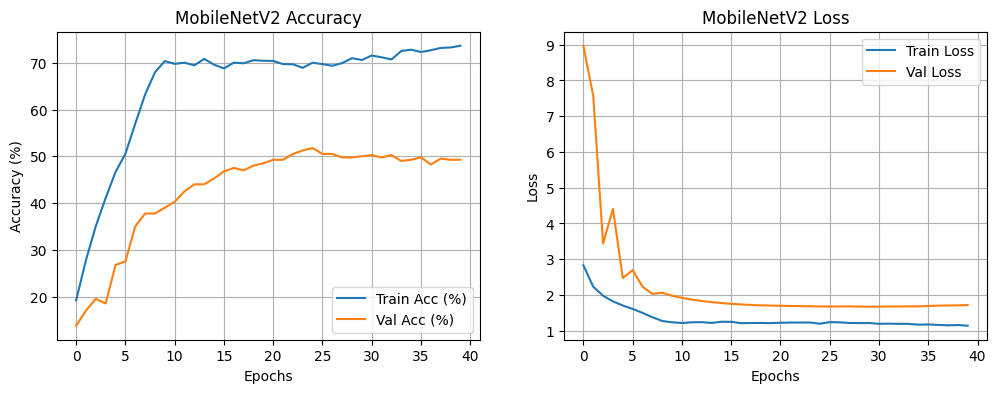

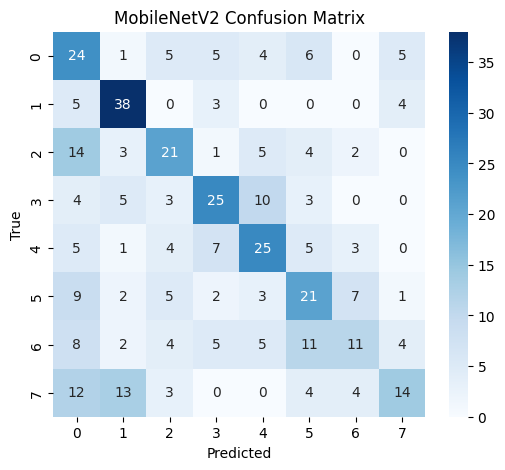

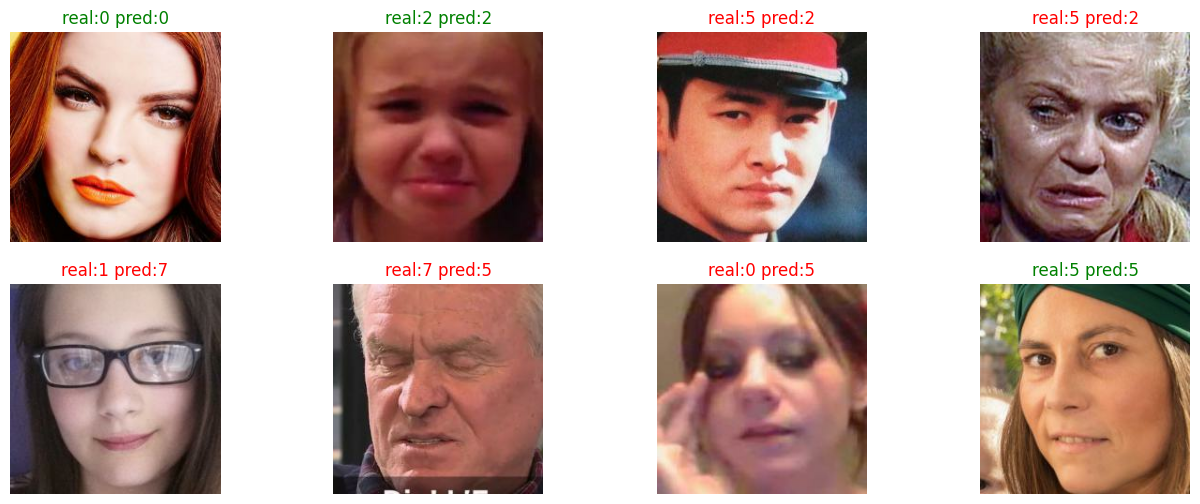


 Evaluating EfficientNetB0
Accuracy: 44.25% | F1: 44.28%
Kappa: 0.3629 | Krippendorff Alpha: 0.3627
AUC: 0.8290 | PR-AUC: 0.4540
RMSE: 0.3587 | Corr: 0.5331
SAGR: 0.6425 | CCC: 0.4860


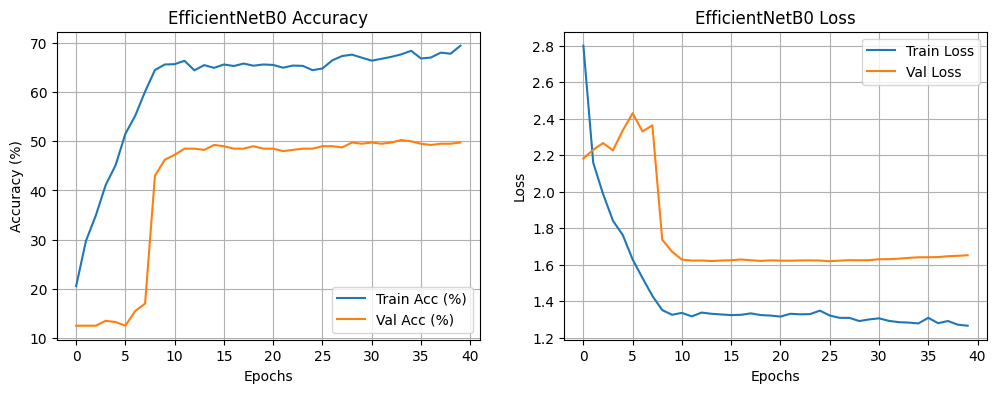

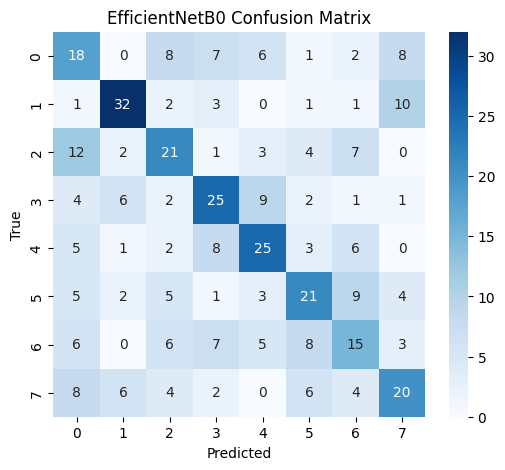

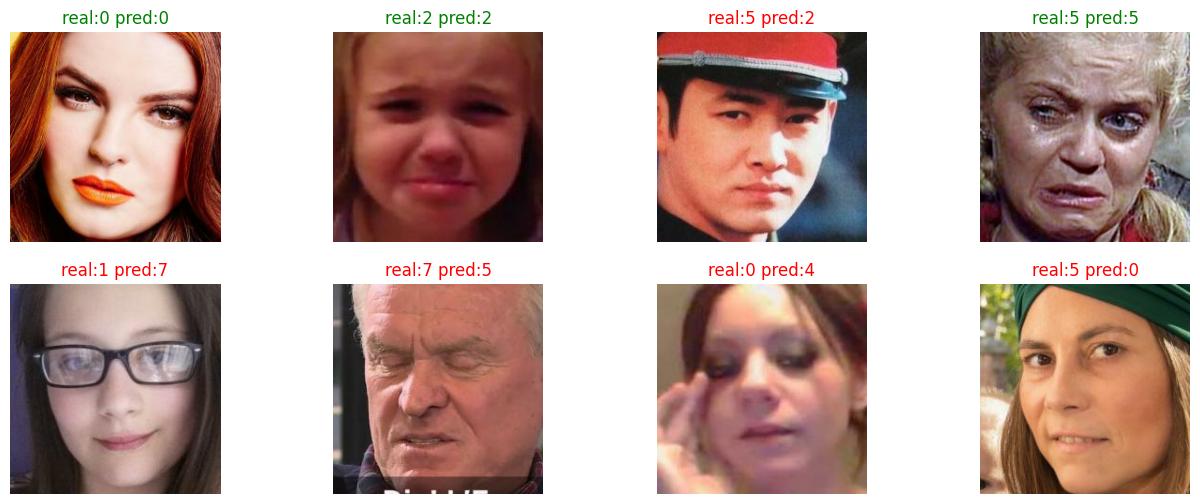


📑 Summary Table:


,Accuracy,F1-weighted,Kappa,Krippendorff Alpha,AUC,PR-AUC,RMSE,Correlation,SAGR,CCC
MobileNetV2,44.75%,43.98%,0.3686,0.3660,0.8305,0.4569,0.3702,0.5144,0.5975,0.4895
EfficientNetB0,44.25%,44.28%,0.3629,0.3627,0.8290,0.4540,0.3587,0.5331,0.6425,0.4860


In [12]:
# --- Evaluate both models ---
results = {}
for name, model, hist in [("MobileNetV2", mobilenet, hist_m_all),
                          ("EfficientNetB0", efficient, hist_e_all)]:
    print(f"\n{'='*50}\n Evaluating {name}\n{'='*50}")
    y_true_exp, y_pred_exp_prob, y_true_va, y_pred_va = gather_predictions(model, test_ds)
    cls_metrics = compute_classification_metrics(y_true_exp, y_pred_exp_prob)
    reg_metrics = compute_regression_metrics(y_true_va, y_pred_va)
    results[name] = {**cls_metrics, **reg_metrics}
    print(f"Accuracy: {cls_metrics['accuracy']*100:.2f}% | F1: {cls_metrics['f1_weighted']*100:.2f}%")
    print(f"Kappa: {cls_metrics['kappa']:.4f} | Krippendorff Alpha: {cls_metrics['krippendorff_alpha']:.4f}")
    print(f"AUC: {cls_metrics['auc_ovr']:.4f} | PR-AUC: {cls_metrics['pr_auc_ovr']:.4f}")
    print(f"RMSE: {reg_metrics['rmse']:.4f} | Corr: {reg_metrics['corr_mean']:.4f}")
    print(f"SAGR: {reg_metrics['sagr']:.4f} | CCC: {reg_metrics['ccc_mean']:.4f}")
    plot_history(hist, title=name)
    plot_confusion_matrix(y_true_exp, cls_metrics['y_pred'], title=f"{name} Confusion Matrix")
    show_examples(model, test_df, n=8)

# --- 📑 Summary table ---
summary = pd.DataFrame(results).T
summary = summary[["accuracy","f1_weighted","kappa","krippendorff_alpha","auc_ovr","pr_auc_ovr","rmse","corr_mean","sagr","ccc_mean"]]
summary = summary.rename(columns={
    "accuracy":"Accuracy","f1_weighted":"F1-weighted","kappa":"Kappa","krippendorff_alpha":"Krippendorff Alpha",
    "auc_ovr":"AUC","pr_auc_ovr":"PR-AUC","rmse":"RMSE","corr_mean":"Correlation","sagr":"SAGR","ccc_mean":"CCC"
})
print("\n📑 Summary Table:")
display(summary.style.format({
    "Accuracy":"{:.2%}","F1-weighted":"{:.2%}","Kappa":"{:.4f}","Krippendorff Alpha":"{:.4f}",
    "AUC":"{:.4f}","PR-AUC":"{:.4f}","RMSE":"{:.4f}","Correlation":"{:.4f}","SAGR":"{:.4f}","CCC":"{:.4f}"
}))



In [13]:
# ------------------------------
# Custom CNN (Extra Credit)
# ------------------------------
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES, dropout=0.4):
    inp = keras.Input(shape=input_shape)

    # Conv Block 1
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Conv Block 2
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Conv Block 3
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Conv Block 4
    x = layers.Conv2D(256, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Shared Dense
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    # Classification head
    cls = layers.Dense(128, activation="relu")(x)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.3)(cls)
    exp_out = layers.Dense(num_classes, activation="softmax", name="exp_out")(cls)

    # Regression head
    reg = layers.Dense(128, activation="relu")(x)
    reg = layers.BatchNormalization()(reg)
    reg = layers.Dropout(0.3)(reg)
    va_out = layers.Dense(2, activation="tanh", name="va_out")(reg)

    return keras.Model(inputs=inp, outputs=[exp_out, va_out], name="CustomCNN")

# ------------------------------
# Train Custom CNN
# ------------------------------
customcnn = build_custom_cnn()
customcnn, hist_c_all = compile_and_train(customcnn, train_ds, val_ds, model_name="CustomCNN")


--- Training CustomCNN Stage 1 ---
Epoch 1/25
100/100 - 35s - 352ms/step - exp_out_accuracy: 0.1344 - exp_out_loss: 2.6358 - loss: 2.8849 - va_out_loss: 0.6229 - va_out_mae: 0.6413 - val_exp_out_accuracy: 0.1450 - val_exp_out_loss: 2.0934 - val_loss: 2.2073 - val_va_out_loss: 0.2758 - val_va_out_mae: 0.4051
Epoch 2/25
100/100 - 6s - 64ms/step - exp_out_accuracy: 0.1319 - exp_out_loss: 2.3667 - loss: 2.5413 - va_out_loss: 0.4363 - va_out_mae: 0.5294 - val_exp_out_accuracy: 0.1475 - val_exp_out_loss: 2.1223 - val_loss: 2.2484 - val_va_out_loss: 0.3138 - val_va_out_mae: 0.4352
Epoch 3/25
100/100 - 6s - 64ms/step - exp_out_accuracy: 0.1410 - exp_out_loss: 2.2959 - loss: 2.4399 - va_out_loss: 0.3600 - va_out_mae: 0.4807 - val_exp_out_accuracy: 0.1400 - val_exp_out_loss: 2.1185 - val_loss: 2.2326 - val_va_out_loss: 0.2790 - val_va_out_mae: 0.4166
Epoch 4/25
100/100 - 6s - 63ms/step - exp_out_accuracy: 0.1275 - exp_out_loss: 2.2655 - loss: 2.3949 - va_out_loss: 0.3234 - va_out_mae: 0.4542 - v


 Evaluating CustomCNN
CustomCNN Accuracy: 12.25%
CustomCNN F1-weighted: 10.86%
CustomCNN Kappa: -0.0029
CustomCNN AUC: 0.5371 | PR-AUC: 0.1458
CustomCNN RMSE: 0.4325 | Corr: 0.0411


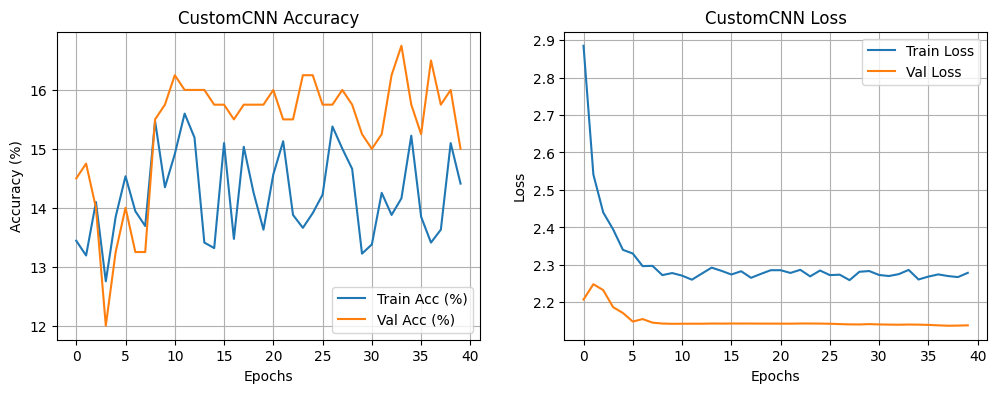

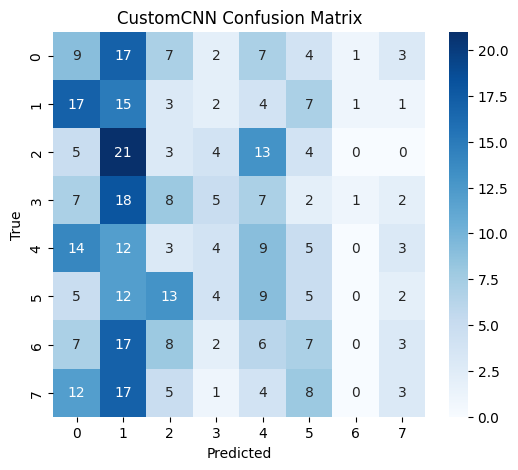

array([[ 9, 17,  7,  2,  7,  4,  1,  3],
       [17, 15,  3,  2,  4,  7,  1,  1],
       [ 5, 21,  3,  4, 13,  4,  0,  0],
       [ 7, 18,  8,  5,  7,  2,  1,  2],
       [14, 12,  3,  4,  9,  5,  0,  3],
       [ 5, 12, 13,  4,  9,  5,  0,  2],
       [ 7, 17,  8,  2,  6,  7,  0,  3],
       [12, 17,  5,  1,  4,  8,  0,  3]])

In [14]:
# ------------------------------
# Evaluate Custom CNN
# ------------------------------
print("\n" + "="*50)
print(" Evaluating CustomCNN")
print("="*50)

y_true_exp, y_pred_exp_prob, y_true_va, y_pred_va = gather_predictions(customcnn, test_ds)

cls_metrics = compute_classification_metrics(y_true_exp, y_pred_exp_prob)
reg_metrics = compute_regression_metrics(y_true_va, y_pred_va)

print(f"CustomCNN Accuracy: {cls_metrics['accuracy']*100:.2f}%")
print(f"CustomCNN F1-weighted: {cls_metrics['f1_weighted']*100:.2f}%")
print(f"CustomCNN Kappa: {cls_metrics['kappa']:.4f}")
print(f"CustomCNN AUC: {cls_metrics['auc_ovr']:.4f} | PR-AUC: {cls_metrics['pr_auc_ovr']:.4f}")
print(f"CustomCNN RMSE: {reg_metrics['rmse']:.4f} | Corr: {reg_metrics['corr_mean']:.4f}")

# Plot training history
plot_history(hist_c_all, title="CustomCNN")

# Confusion matrix
plot_confusion_matrix(y_true_exp, cls_metrics['y_pred'], title="CustomCNN Confusion Matrix")


## Custom CNN Training Results

The Custom CNN model was trained from scratch on the same dataset.

- **Stage 1:** Loss decreased from ~2.86 → ~2.14, Valence-Arousal MAE improved from 0.63 → 0.36.  
- **Stage 2 (Fine-tuning):** Accuracy stabilized around **16–17%**, MAE ~0.36.  

### Key Observations:
- Unlike MobileNetV2 and EfficientNetB0, which leverage pretrained ImageNet features, the Custom CNN struggles to generalize due to limited data and smaller capacity.
- **Regression head** performs decently, learning valence-arousal trends.
- **Classification head** underperforms since it needs much more data to learn robust features.
